# Modelo de Clasificación de Imágenes de Basura

Carlos Iván Fonseca Mondragón | A01771689

In [1]:
# Importación de librerías
import joblib
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2 as kernel_regularizer_l2

In [2]:
# Verificar si TensorFlow detecta la GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("GPU detectada:", physical_devices)
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("No se detectó GPU. Usando CPU.")

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cargar datasets preprocesados

In [3]:
# Cargar metadatos
metadata = joblib.load("processed_datasets/metadata.pkl")

class_names = metadata["class_names"]
class_weights = metadata["class_weights"]
image_size = tuple(metadata["image_size"])
batch_size = metadata["batch_size"]
num_classes = metadata["num_classes"]

print("Metadatos cargados:")
print(f"  Clases: {class_names}")
print(f"  Pesos de clase: {class_weights}")
print(f"  Número de clases: {num_classes}")
print(f"  Tamaño de imagen: {image_size}")
print(f"  Tamaño de batch: {batch_size}")

Metadatos cargados:
  Clases: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
  Pesos de clase: {0: 1.0876190476190477, 1: 1.2903954802259887, 2: 1.2440087145969498, 3: 0.6737463126843658, 4: 1.084520417853751, 5: 1.054478301015697, 6: 0.5758951084215834, 7: 1.655072463768116, 8: 1.239956568946797}
  Número de clases: 9
  Tamaño de imagen: (224, 224)
  Tamaño de batch: 32


In [4]:
# Cargar datasets preprocesados

train_dataset_raw = tf.data.Dataset.load("processed_datasets/train")
normalized_validation_dataset = tf.data.Dataset.load("processed_datasets/validation")
normalized_test_dataset = tf.data.Dataset.load("processed_datasets/test")

print(f"Train dataset: {len(train_dataset_raw)} batches")
print(f"Validation dataset: {len(normalized_validation_dataset)} batches")
print(f"Test dataset: {len(normalized_test_dataset)} batches")

Train dataset: 108 batches
Validation dataset: 12 batches
Test dataset: 30 batches


2026-06-06 14:06:33.403593: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-06-06 14:06:33.403614: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-06-06 14:06:33.403623: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
2026-06-06 14:06:33.403639: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-06 14:06:33.403649: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Data Augmentation

In [5]:
# Definir capas de augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

def augment_images(x, y):
    return data_augmentation(x, training=True), y

# Aplicar augmentation al dataset de entrenamiento
augmented_train_dataset = (
    train_dataset_raw
    .map(augment_images, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .prefetch(tf.data.AUTOTUNE)
)

## Definición del modelo

In [6]:
# Arquitectura del modelo de 5 capas convolucionales
model = tf.keras.Sequential([
    Input(shape=(224, 224, 3)),
    
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(512, (3,3), activation='relu', padding='same', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(1024, (3,3), activation='relu', padding='same', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu', kernel_regularizer=kernel_regularizer_l2(1e-4)),
    Dropout(0.6),

    Dense(num_classes, activation='softmax')
])

In [7]:
# Compilar modelo
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print("\nResumen del modelo:")
model.summary()


Resumen del modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,560,969 (25.03 MB)

 Trainable params: 6,556,937 (25.01 MB)

 Non-trainable params: 4,032 (15.75 KB)

## Entrenamiento

In [ ]:
# Configurar callbacks
EPOCHS = 50

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model_experimental.keras", 
        save_best_only=True, 
        monitor='val_accuracy',
        mode="max"
    ),
    
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', 
        factor=0.5, 
        patience=15, 
        min_lr=1e-7,
        mode="max",
    ),
    
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=30, 
        restore_best_weights=True,
        mode="max",

    )
]

In [9]:
# Entrenar el modelo
history = model.fit(
    augmented_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    # class_weight=class_weights (deprecado en el modelo actual, pues genera mucha variación en el accuracy, pero se mantiene por si puede ser de utilidad al implementar una mejora)
)

Epoch 1/50


2026-06-06 14:06:34.811851: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 146ms/step - accuracy: 0.3640 - loss: 3.4233 - val_accuracy: 0.0789 - val_loss: 3.4945 - learning_rate: 1.0000e-04
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.4224 - loss: 2.8793 - val_accuracy: 0.0789 - val_loss: 6.9614 - learning_rate: 1.0000e-04
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.4492 - loss: 2.8471 - val_accuracy: 0.0816 - val_loss: 8.0380 - learning_rate: 1.0000e-04
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - accuracy: 0.4673 - loss: 2.8691 - val_accuracy: 0.2658 - val_loss: 4.4586 - learning_rate: 1.0000e-04
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - accuracy: 0.4819 - loss: 2.8279 - val_accuracy: 0.4474 - val_loss: 2.8451 - learning_rate: 1.0000e-04
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - accuracy: 0.4939 - loss: 2.7993 - val_accuracy: 0.4816 - val_loss: 2.8873 - learning_rate: 1.0000e-04
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step - 

## Evaluación en datos de prueba

In [10]:
# Evaluar en test dataset
test_loss, test_accuracy = model.evaluate(
    normalized_test_dataset,
)

print(f"\nResultados en Test Dataset:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6813 - loss: 2.2476

Resultados en Test Dataset:
Loss: 2.2476
Accuracy: 0.6813


## Visualización de resultados

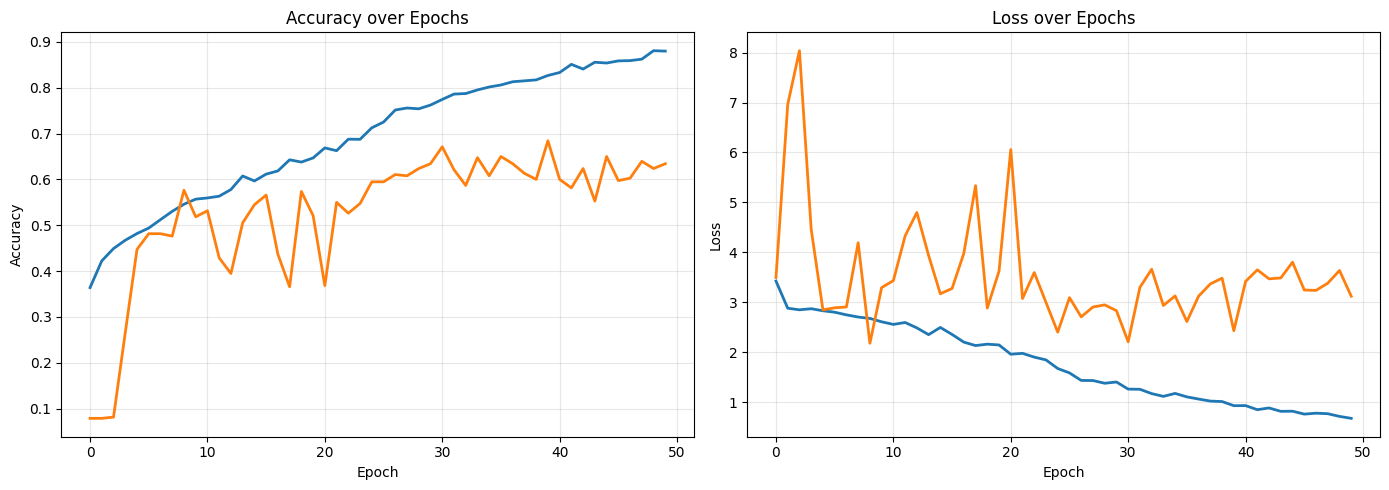


Mejor validación Accuracy: 0.6842
Mejor validación Loss: 2.1773


In [11]:
# Obtener historial de entrenamiento
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

# Gráficos
plt.figure(figsize=(14, 5))

# Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMejor validación Accuracy: {max(val_acc):.4f}")
print(f"Mejor validación Loss: {min(val_loss):.4f}")

### Matriz de Confusión

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

2026-06-06 14:20:53.993319: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


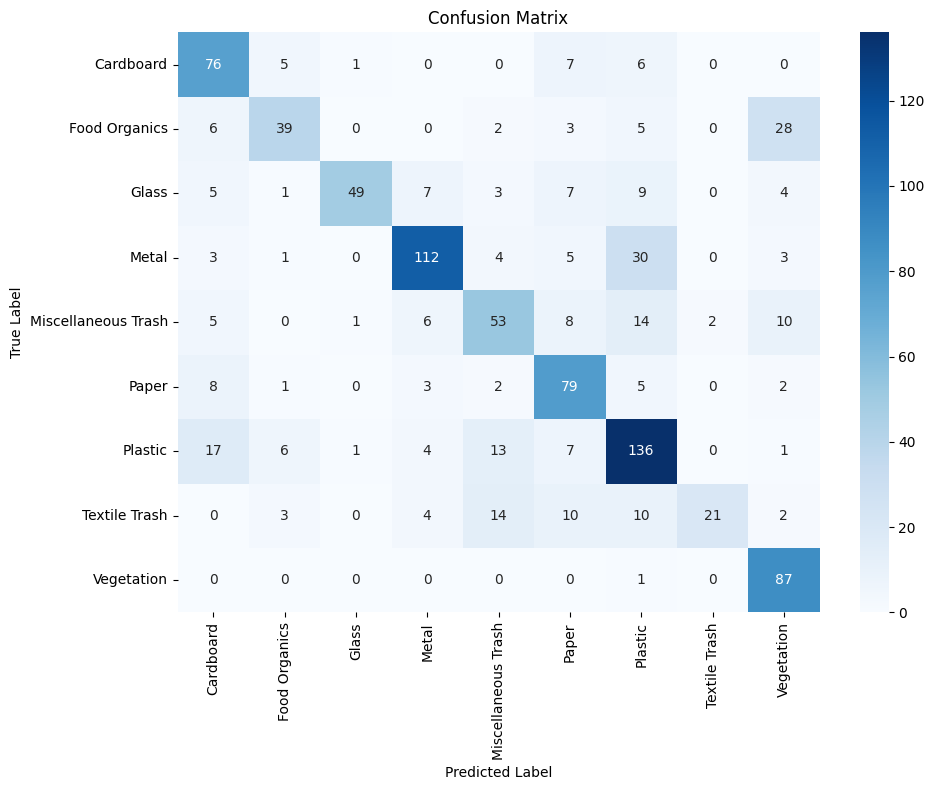

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

# Obtener predicciones y etiquetas reales
y_true = []
y_pred = []

for images, labels in normalized_test_dataset:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [13]:
# Reporte de clasificación
print("\n" + "="*60)
print("                   CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))


                   CLASSIFICATION REPORT
                     precision    recall  f1-score   support

          Cardboard       0.63      0.80      0.71        95
      Food Organics       0.70      0.47      0.56        83
              Glass       0.94      0.58      0.72        85
              Metal       0.82      0.71      0.76       158
Miscellaneous Trash       0.58      0.54      0.56        99
              Paper       0.63      0.79      0.70       100
            Plastic       0.63      0.74      0.68       185
      Textile Trash       0.91      0.33      0.48        64
         Vegetation       0.64      0.99      0.77        88

           accuracy                           0.68       957
          macro avg       0.72      0.66      0.66       957
       weighted avg       0.71      0.68      0.67       957



## Guardar modelo final

In [14]:
model.save("modelo_experimental.keras")
print("Modelo guardado como: modelo_experimental.keras")
print("Mejor modelo guardado como: best_model_experimental.keras")

Modelo guardado como: modelo_experimental.keras
Mejor modelo guardado como: best_model_experimental.keras
